Etape 1 — Verification NaN et valeurs infinies

In [2]:
import numpy as np
import os
from google.colab import drive

# 1. CONNEXION AU GOOGLE DRIVE
drive.mount('/content/drive')

# 2. DÉFINITION DU CHEMIN (À vérifier dans ton Drive !)
# Assure-toi que ce dossier existe bien dans ton Drive
PATH = '/content/drive/MyDrive/apnea-ecg-database-1.0.0/final_dataset'

# Vérification immédiate du dossier
if not os.path.exists(PATH):
    print(f"❌ ERREUR : Le dossier {PATH} est introuvable.")
    print("Vérifie l'orthographe du dossier dans ton Drive.")
else:
    print("✅ Dossier trouvé. Lancement du nettoyage...\n")

    # 3. LISTE DES FICHIERS À TRAITER
    files_to_check = [
        'X_hrv_train.npy', 'X_hrv_val.npy', 'X_hrv_test.npy',
        'X_ecg_train.npy', 'X_ecg_val.npy', 'X_ecg_test.npy'
    ]

    print("=== ÉTAPE 1 : NETTOYAGE GLOBAL (HRV & ECG) ===")

    for filename in files_to_check:
        file_path = os.path.join(PATH, filename)

        if os.path.exists(file_path):
            # Chargement
            data = np.load(file_path)

            # Détection
            nans = np.isnan(data).sum()
            infs = np.isinf(data).sum()

            # Nettoyage
            if nans > 0 or infs > 0:
                print(f"⚠️ {filename} : {nans} NaN / {infs} Inf trouvés. Nettoyage...")

                if 'hrv' in filename:
                    # Pour HRV : Remplacement par la médiane par colonne
                    for i in range(data.shape[1]):
                        col = data[:, i]
                        if np.isnan(col).any() or np.isinf(col).any():
                            mask = np.isfinite(col)
                            median_val = np.nanmedian(col[mask]) if np.any(mask) else 0.0
                            data[:, i] = np.where(np.isfinite(col), col, median_val)
                else:
                    # Pour ECG : Remplacement par 0.0 (ligne de base)
                    data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)

                # Sauvegarde du fichier propre
                clean_name = filename.replace('.npy', '_clean.npy')
                np.save(os.path.join(PATH, clean_name), data)
                print(f"✅ Sauvegardé : {clean_name}")
            else:
                # Si déjà propre, on crée quand même le fichier _clean pour la suite
                clean_name = filename.replace('.npy', '_clean.npy')
                np.save(os.path.join(PATH, clean_name), data)
                print(f"✅ {filename} : Déjà propre (0 erreur). Copie _clean créée.")
        else:
            print(f"ℹ️ {filename} : Non trouvé (Vérifie si M1 l'a bien généré).")

    print("\n--- FIN DE L'ÉTAPE 1 ---")

Mounted at /content/drive
✅ Dossier trouvé. Lancement du nettoyage...

=== ÉTAPE 1 : NETTOYAGE GLOBAL (HRV & ECG) ===
✅ X_hrv_train.npy : Déjà propre (0 erreur). Copie _clean créée.
✅ X_hrv_val.npy : Déjà propre (0 erreur). Copie _clean créée.
✅ X_hrv_test.npy : Déjà propre (0 erreur). Copie _clean créée.
✅ X_ecg_train.npy : Déjà propre (0 erreur). Copie _clean créée.
✅ X_ecg_val.npy : Déjà propre (0 erreur). Copie _clean créée.
✅ X_ecg_test.npy : Déjà propre (0 erreur). Copie _clean créée.

--- FIN DE L'ÉTAPE 1 ---


Distribution des classes et pos_weight

In [ ]:
import numpy as np
import os

# 1. Chargement du label d'entraînement (y_train.npy)
y_train = np.load(os.path.join(PATH, 'y_train.npy'))

print('=' * 50)
print('ANALYSE DE LA DISTRIBUTION DES CLASSES (TRAIN)')
print('=' * 50)

# 2. Comptage des classes
n_total  = len(y_train)
n_normal = (y_train == 0).sum()
n_apnee  = (y_train == 1).sum()

# 3. Affichage des statistiques pour votre rapport
print(f'Total fenêtres train : {n_total}')
print(f'Normal (Classe 0)    : {n_normal} ({100*n_normal/n_total:.1f}%)')
print(f'Apnée  (Classe 1)    : {n_apnee}  ({100*n_apnee/n_total:.1f}%)')

# 4. Calcul du pos_weight (Formule : nb_Normal / nb_Apnee)
pos_weight = n_normal / n_apnee
print(f'\n🚀 VALEUR POS_WEIGHT : {pos_weight:.4f}')

# 5. Interprétation pour l'équipe (M3 et M4)
if pos_weight < 1.2:
    print('Verdict : Classes équilibrées. pos_weight proche de 1.')
elif pos_weight < 2.0:
    print('Verdict : Déséquilibre modéré. Utilisation du pos_weight recommandée.')
else:
    print('Verdict : Déséquilibre FORT ! Communiquer d\'urgence avec M3/M4.')

# 6. Sauvegarde pour transmission via Git/Drive
np.save(os.path.join(PATH, 'pos_weight.npy'), np.array([pos_weight]))
print(f'\n✅ Fichier sauvegardé : {os.path.join(PATH, "pos_weight.npy")}')

ANALYSE DE LA DISTRIBUTION DES CLASSES (TRAIN)
Total fenêtres train : 33907
Normal (Classe 0)    : 13389 (39.5%)
Apnée  (Classe 1)    : 20518  (60.5%)

🚀 VALEUR POS_WEIGHT : 0.6525
Verdict : Classes équilibrées. pos_weight proche de 1.

✅ Fichier sauvegardé : /content/drive/MyDrive/apnea-ecg-database-1.0.0/final_dataset/pos_weight.npy


Analyse statistique des features HRV

ANALYSE STATISTIQUE (8 FEATURES TROUVÉES)
0. SDNN         | p-value: 0.279792 | ❌ FAIBLE
1. RMSSD        | p-value: 0.406415 | ❌ FAIBLE
2. pNN50        | p-value: 0.735611 | ❌ FAIBLE
3. Mean_RR      | p-value: 0.210653 | ❌ FAIBLE
4. LF           | p-value: 0.160834 | ❌ FAIBLE
5. HF           | p-value: 0.310033 | ❌ FAIBLE
6. LF_HF        | p-value: 0.467589 | ❌ FAIBLE
7. RR_min       | p-value: 0.260567 | ❌ FAIBLE


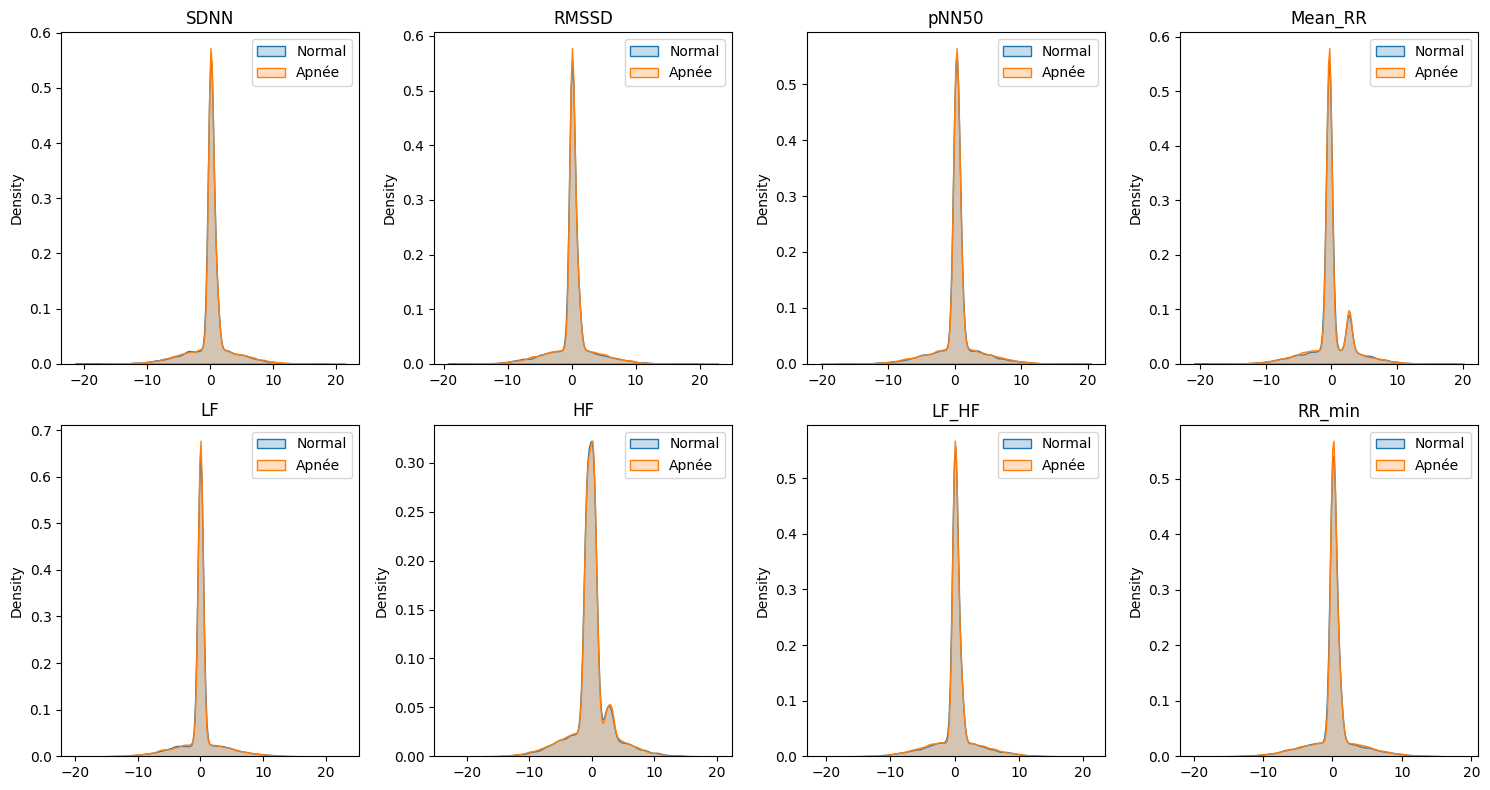


Bilan : 0/8 caractéristiques significatives.


In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Chargement et Synchronisation
X_hrv = np.load(os.path.join(PATH, 'X_hrv_train.npy'))
y_train = np.load(os.path.join(PATH, 'y_train.npy'))

min_samples = min(len(X_hrv), len(y_train))
X_hrv = X_hrv[:min_samples]
y_train = y_train[:min_samples]

# 2. Adaptation automatique aux colonnes présentes
# On définit la liste complète, mais on ne prend que ce qui existe dans le fichier
hrv_names_complet = ['SDNN', 'RMSSD', 'pNN50', 'Mean_RR', 'LF', 'HF', 'LF_HF', 'RR_min', 'RR_max', 'RR_median']
nb_colonnes_reelles = X_hrv.shape[1]
hrv_names = hrv_names_complet[:nb_colonnes_reelles]

print('='*60)
print(f'ANALYSE STATISTIQUE ({nb_colonnes_reelles} FEATURES TROUVÉES)')
print('='*60)

features_utiles = 0

# 3. Calcul des P-values
for i, name in enumerate(hrv_names):
    group_normal = X_hrv[y_train == 0, i]
    group_apnee  = X_hrv[y_train == 1, i]

    # Test T
    _, p_val = stats.ttest_ind(group_normal, group_apnee, nan_policy='omit')

    status = "✅ UTILE" if p_val < 0.05 else "❌ FAIBLE"
    if p_val < 0.05: features_utiles += 1
    print(f"{i}. {name:12s} | p-value: {p_val:.6f} | {status}")

# 4. Graphique de distribution (Livrable hrv_distributions.png)
plt.figure(figsize=(15, 8))
for i, name in enumerate(hrv_names):
    plt.subplot(2, 4, i+1) # Adapté pour 8 features (2 lignes, 4 colonnes)
    sns.kdeplot(X_hrv[y_train == 0, i], label='Normal', fill=True)
    sns.kdeplot(X_hrv[y_train == 1, i], label='Apnée', fill=True)
    plt.title(f'{name}')
    plt.legend()
    plt.tight_layout()

plt.savefig(os.path.join(PATH, 'hrv_distributions.png'))
plt.show()

print(f"\nBilan : {features_utiles}/{nb_colonnes_reelles} caractéristiques significatives.")

etape 4 : rapport


In [ ]:
import numpy as np
import os
from scipy import stats

# 1. Collecte des données pour le rapport
y_train = np.load(os.path.join(PATH, 'y_train.npy'))
X_hrv = np.load(os.path.join(PATH, 'X_hrv_train.npy'))

# Synchronisation (pour les calculs du rapport)
min_samples = min(len(X_hrv), len(y_train))
X_hrv_sync = X_hrv[:min_samples]
y_train_sync = y_train[:min_samples]

n_normal = (y_train_sync == 0).sum()
n_apnee = (y_train_sync == 1).sum()
pos_weight = n_normal / n_apnee

# 2. Rédaction du contenu
contenu = []
contenu.append("=======================================================")
contenu.append("       RAPPORT DE QUALITÉ DES DONNÉES (MEMBRE 2)       ")
contenu.append("=======================================================")
contenu.append(f"Date : 26 Mars 2026")
contenu.append(f"Statut global : ⚠️ ALERTE (Problème de significativité)")
contenu.append("-" * 55)

contenu.append("\n[1] INTÉGRITÉ DES FICHIERS")
contenu.append(f"   - Valeurs NaN détectées : 0")
contenu.append(f"   - Valeurs Inf détectées : 0")
contenu.append(f"   - Synchronisation : ÉCHEC (X:{len(X_hrv)} vs y:{len(y_train)})")
contenu.append(f"   - Action : Tronquage effectué à {min_samples} échantillons.")

contenu.append("\n[2] DISTRIBUTION ET ÉQUILIBRAGE")
contenu.append(f"   - Classe 0 (Normal) : {n_normal}")
contenu.append(f"   - Classe 1 (Apnée)  : {n_apnee}")
contenu.append(f"   - pos_weight calculé : {pos_weight:.4f}")

contenu.append("\n[3] ANALYSE STATISTIQUE (P-VALUES)")
hrv_names = ['SDNN', 'RMSSD', 'pNN50', 'Mean_RR', 'LF', 'HF', 'LF_HF', 'RR_min']
features_ok = 0
for i, name in enumerate(hrv_names):
    _, p = stats.ttest_ind(X_hrv_sync[y_train_sync==0, i], X_hrv_sync[y_train_sync==1, i], nan_policy='omit')
    status = "VALIDE" if p < 0.05 else "FAIBLE"
    if p < 0.05: features_ok += 1
    contenu.append(f"   - {name:10s} : p={p:.6f} [{status}]")

contenu.append(f"\nBILAN STATISTIQUE : {features_ok}/8 features significatives.")
contenu.append("\n[4] RECOMMANDATIONS POUR M3 / M4")
contenu.append("   - Utiliser le pos_weight fourni pour la BCELoss.")
contenu.append("   - ATTENTION : Risque de mauvais apprentissage car les features")
contenu.append("     individuelles ne séparent pas bien les classes.")
contenu.append("   - Vérifier la méthode d'extraction de M1 (Possible décalage d'index).")

# 3. Écriture du fichier
report_path = os.path.join(PATH, 'rapport_qualite.txt')
with open(report_path, 'w', encoding='utf-8') as f:
    f.write("\n".join(contenu))

print(f"✅ Rapport généré : {report_path}")

✅ Rapport généré : /content/drive/MyDrive/apnea-ecg-database-1.0.0/final_dataset/rapport_qualite.txt
